2026-02-21 00:20:58 – 2026-02-21 05:28:33  |  05:07:34
Samples: 4505771  |  fs: 250.00 Hz  |  Beats: 19122
Mean HR: 64 bpm  |  SDNN: 120 ms  |  RMSSD: 72 ms


<Axes: >

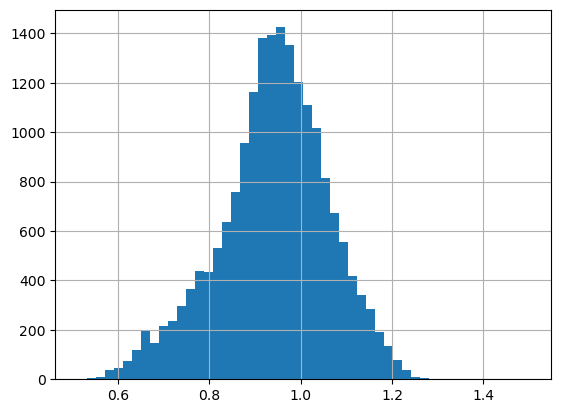

In [153]:
from rr_hr_hrv import *
ecg = pd.read_parquet('ecg_log_2026-02-21_002056.parquet')
#ecg['time'] -= ecg['time'].values[0]
ecg_t0 = ecg['time'].values[0]
ecg = ecg[(ecg['time'] < ecg_t0+18455) & (ecg['time'] < ecg_t0+18455) ]
lead_off_idx = ecg[ecg['lead'] == 1].index
ecg = ecg[ecg['lead'] == 0]

ecg_beats = BeatCalc(ecg)
print(ecg_beats.ecg_info())
pd.Series(ecg_beats.rr_clean).hist(bins=50)

## nk 和我手搓阈值的差别

In [155]:
my_rpeaks = ecg_beats.peaks
my_rr = ecg_beats.rr_clean
nk_rpeaks = np.load('rpeaks_nk.npy')
nk_rr = np.load('all_rr_nk.npy')

In [156]:
import numpy as np
import pandas as pd

def match_peaks_by_index(ref, test, tol=20):
    """
    ref/test: 递增的样本点索引 (int array)
    tol: 允许的最大偏差（样本点数）
    返回：match_df, ref_miss_idx, test_extra_idx
    """
    ref = np.asarray(ref, dtype=int)
    test = np.asarray(test, dtype=int)

    j = 0
    used_test = np.zeros(len(test), dtype=bool)
    rows = []
    miss_ref = []

    for i, r in enumerate(ref):
        # 移动 j 到 test 中最接近 r 的附近
        while j + 1 < len(test) and test[j + 1] <= r:
            j += 1

        cand = []
        if j < len(test): cand.append(j)
        if j + 1 < len(test): cand.append(j + 1)

        best_k, best_d = None, None
        for k in cand:
            d = abs(test[k] - r)
            if best_d is None or d < best_d:
                best_k, best_d = k, d

        if best_k is not None and best_d <= tol:
            rows.append((i, best_k, r, test[best_k], best_d))
            used_test[best_k] = True
        else:
            miss_ref.append(i)

    extra_test = np.where(~used_test)[0]
    match_df = pd.DataFrame(rows, columns=["ref_i","test_i","ref_peak","test_peak","abs_diff_samples"])
    return match_df, np.asarray(miss_ref), extra_test

In [137]:
import matplotlib.pyplot as plt

def sweep_tol_log(nk_rpeaks, my_rpeaks,
                  tol_min=1, tol_max=200, n=30,
                  base=10, use_int=True):
    """
    tol_min/tol_max: 样本点容忍范围
    n: 采样点数
    base: 对数底（10常用）
    use_int: tol 是否取整（推荐 True，因为 tol 是样本点）
    """
    nk_rpeaks = np.asarray(nk_rpeaks, dtype=int)
    my_rpeaks = np.asarray(my_rpeaks, dtype=int)

    # 生成对数间隔 tol
    t = np.logspace(np.log10(tol_min), np.log10(tol_max), num=n, base=base)
    if use_int:
        t = np.unique(np.round(t).astype(int))  # 去重+取整

    rows = []
    for tol in t:
        match_df, nk_miss, my_extra = match_peaks_by_index(nk_rpeaks, my_rpeaks, tol=int(tol))
        rows.append({
            "tol": int(tol),
            "match": len(match_df),
            "nk_miss": len(nk_miss),      # nk有但你没匹配到（相对nk的漏检）
            "my_extra": len(my_extra),    # 你有但nk没匹配到（相对nk的疑似误检）
            "nk_total": len(nk_rpeaks),
            "my_total": len(my_rpeaks),
            "miss_rate": len(nk_miss) / max(1, len(nk_rpeaks)),
            "extra_rate": len(my_extra) / max(1, len(my_rpeaks)),
        })

    return pd.DataFrame(rows)

def plot_tol_sweep(df_sweep, title="Peak matching vs tolerance"):
    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(df_sweep["tol"], df_sweep["nk_miss"], marker="o", markersize=3, linewidth=1.5, label="nk miss (your miss vs NK)")
    ax.plot(df_sweep["tol"], df_sweep["my_extra"], marker="o", markersize=3, linewidth=1.5, label="my extra (your extra vs NK)")

    ax.set_xscale("log")
    ax.set_xlabel("tolerance (samples, log scale)")
    ax.set_ylabel("count")
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
    return fig, ax

def plot_tol_sweep_rate(df_sweep, title="Miss/extra rate vs tolerance"):
    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(df_sweep["tol"], df_sweep["miss_rate"], marker="o", markersize=3, linewidth=1.5, label="nk miss rate")
    ax.plot(df_sweep["tol"], df_sweep["extra_rate"], marker="o", markersize=3, linewidth=1.5, label="my extra rate")

    ax.set_xscale("log")
    ax.set_xlabel("tolerance (samples, log scale)")
    ax.set_ylabel("rate")
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
    return fig, ax

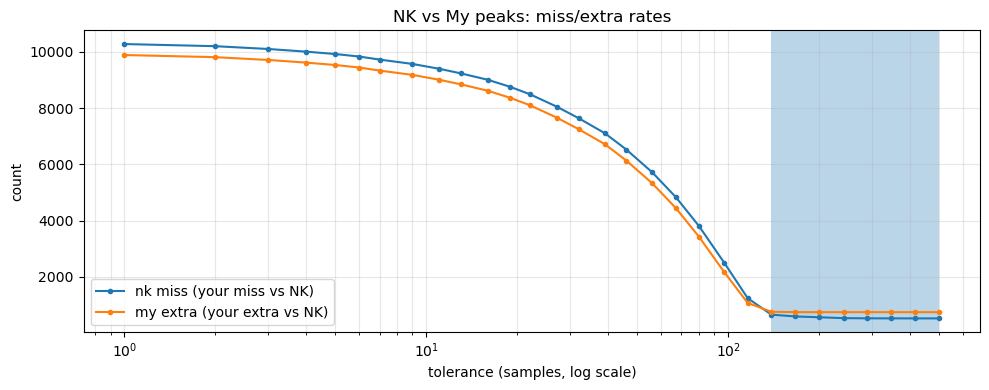

In [157]:
df_sweep = sweep_tol_log(nk_rpeaks, my_rpeaks, tol_min=1, tol_max=500, n=35)
#plot_tol_sweep(df_sweep, title="NK vs My peaks: miss/extra counts")

fig, ax = plot_tol_sweep(
    df_sweep, 
    title="NK vs My peaks: miss/extra rates"
    )
ax.axvspan(df_sweep.loc[22, "tol"], df_sweep["tol"].values[-1], alpha=0.3)

plt.tight_layout()
plt.savefig('plot_tol_sweep.jpg', dpi=300)

In [158]:
match_df, nk_miss, my_extra = match_peaks_by_index(nk_rpeaks, my_rpeaks, tol=500)
print("match:", len(match_df))
print("nk miss (你漏掉 nk 的):", len(nk_miss))
print("my extra (你多出来的):", len(my_extra))
match_df.tail()

match: 18989
nk miss (你漏掉 nk 的): 523
my extra (你多出来的): 745


,ref_i,test_i,ref_peak,test_peak,abs_diff_samples
18984,18984,19119,4505118,4505151,33
18985,18985,19120,4505358,4505365,7
18986,18986,19121,4505582,4505591,9
18987,18987,19121,4505788,4505591,197
18988,18988,19121,4505975,4505591,384


## 包含所有连续时间戳的ecg

In [127]:
ecg = pd.read_parquet('ecg_log_2026-02-21_002056.parquet')
nk_miss_idx = nk_rpeaks[nk_miss]
my_extra_idx = ecg_beats.peaks[my_extra]
ecg["nk_miss"] = 0
ecg["my_extra"] = 0

ecg.loc[nk_miss_idx, "nk_miss"] = 1
ecg.loc[my_extra_idx, "my_extra"] = 1

ecg.to_parquet('ecg_nk_my_diff.parquet')